In [1]:
### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime
import h5py
import numpy as np
np.set_printoptions(suppress=True)

# example for ENA
### but if you need SGP:
- replace any 'ENA' to 'SGP'.

In [2]:
ds_ca = xr.open_dataset('/data/ggong/CloudSat/matched_CCM/CALIPSO_ENA.nc')
ds_csm = xr.open_dataset('/data/ggong/CloudSat/matched_CCM/Cloudsat_MODIS_ENA.nc')

In [6]:
import numpy as np

# -------------------------
# 0) Sanity check: sample dimensions must match
# -------------------------
assert ds_ca.sizes["sample"] == ds_csm.sizes["sample"], (
    ds_ca.sizes["sample"], ds_csm.sizes["sample"]
)

# -------------------------
# 1) Dust extinction from CALIPSO
# -------------------------
dust_ext = (
    ds_ca["Pure_Dust_Fine_Extinction_Coefficient_532"].values +
    ds_ca["Pure_Dust_Coarse_Extinction_Coefficient_532"].values
)

height = ds_ca["height"].values  # km
dz = np.gradient(height)         # km

# -------------------------
# 2) Cloud base/top from CloudSat-MODIS
# -------------------------
cloud_base = ds_csm["cs_CloudLayerBase_mean"].values.astype(float)  # km
cloud_top  = ds_csm["cs_CloudLayerTop_mean"].values.astype(float)   # km

# -------------------------
# 3) Identify the dominant dust layer
# -------------------------
n = dust_ext.shape[0]
dust_base = np.full(n, np.nan)
dust_top  = np.full(n, np.nan)

for i, ext in enumerate(dust_ext):
    mask = np.isfinite(ext) & (ext > 0)
    if mask.sum() < 2:
        continue

    idx = np.where(mask)[0]
    layers = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)

    dod = [np.sum(ext[layer] * dz[layer]) for layer in layers]
    main = layers[np.argmax(dod)]

    dust_base[i] = height[main[0]]
    dust_top[i]  = height[main[-1]]

# -------------------------
# 4) Classify dust-cloud vertical configurations
# -------------------------
thr = 0.1  # km

valid = (
    np.isfinite(dust_base) & np.isfinite(dust_top) &
    np.isfinite(cloud_base) & np.isfinite(cloud_top)
)

top_mask = valid & ((dust_base - cloud_top) >= thr)
bot_mask = valid & ((cloud_base - dust_top) >= thr)
mid_mask = valid & (np.abs(dust_top - cloud_top) <= thr) & (np.abs(cloud_base - dust_base) <= thr)

cats = {
    "top": top_mask,
    "middle": mid_mask,
    "bottom": bot_mask,
}

print("Top cases:", int(top_mask.sum()))
print("Middle cases:", int(mid_mask.sum()))
print("Bottom cases:", int(bot_mask.sum()))
print("Total classified:", int(top_mask.sum() + mid_mask.sum() + bot_mask.sum()))
print("Total valid:", int(valid.sum()))

cloud_mh = (cloud_base + cloud_top) / 2
dust_mh  = (dust_base + dust_top) / 2

cloud_mh_by_cat = {k: cloud_mh[m] for k, m in cats.items()}
dust_mh_by_cat  = {k: dust_mh[m]  for k, m in cats.items()}

Top cases: 339
Middle cases: 41
Bottom cases: 112
Total classified: 492
Total valid: 820


## Group to dataframe for easier visualization

In [7]:
import numpy as np
import pandas as pd

# ---------- Dust layer from CALIPSO ----------
h = ds_ca["height"].values.astype(float)      # km
dz = np.gradient(h)                           # km

dust = (
    ds_ca["Pure_Dust_Fine_Extinction_Coefficient_532"].values.astype(float) +
    ds_ca["Pure_Dust_Coarse_Extinction_Coefficient_532"].values.astype(float)
)

n = dust.shape[0]
db_km = np.full(n, np.nan)       # dominant dust-layer base
dt_km = np.full(n, np.nan)       # dominant dust-layer top
main_DOD = np.full(n, np.nan)    # DOD of the dominant dust layer

for i, ext in enumerate(dust):
    mask = np.isfinite(ext) & (ext > 0)
    if mask.sum() < 2:
        continue

    idx = np.where(mask)[0]
    layers = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)

    layer_dod = np.array([np.sum(ext[L] * dz[L]) for L in layers])
    L = layers[np.argmax(layer_dod)]

    db_km[i] = h[L[0]]
    dt_km[i] = h[L[-1]]
    main_DOD[i] = layer_dod.max()

# ---------- Cloud and MODIS variables ----------
cb_km = ds_csm["cs_CloudLayerBase_mean"].values.astype(float)
ct_km = ds_csm["cs_CloudLayerTop_mean"].values.astype(float)

COD = ds_csm["COD_1621"].values.astype(float)
LWP = ds_csm["CWP_1621"].values.astype(float)
Re  = ds_csm["re_1621"].values.astype(float)

cs_LWP = ds_csm["cs_Cloud_Liq_Water_Path_mean"].values.astype(float)
cs_Re  = ds_csm["cs_Liq_Geom_Mean_Radius_mean"].values.astype(float)

for x in [COD, LWP, Re, cs_LWP, cs_Re]:
    x[x <= -9000] = np.nan

# ---------- Time information ----------
time_round = (ds_csm["time"].values + np.timedelta64(30, "m")).astype("datetime64[h]")
dtp = pd.to_datetime(time_round)

# ---------- Dust-cloud vertical classification ----------
thr = 100  # m

db_m, dt_m = db_km * 1000, dt_km * 1000
cb_m, ct_m = cb_km * 1000, ct_km * 1000

valid = np.isfinite(db_m) & np.isfinite(dt_m) & np.isfinite(cb_m) & np.isfinite(ct_m)

cat = np.full(n, "unclassified", dtype=object)
cat[valid & (db_m - ct_m >= thr)] = "top"
cat[valid & (cb_m - dt_m >= thr)] = "bottom"
cat[valid & (np.abs(dt_m - ct_m) <= thr) & (np.abs(cb_m - db_m) <= thr)] = "middle"

# ---------- Final analysis table ----------
df = pd.DataFrame({
    "cat": cat,
    "month": dtp.month.values,
    "hour_round": dtp.hour.values,
    "DOD": main_DOD,
    "COD": COD,
    "LWP": LWP,
    "Re": Re,
    "cloud_base_km": cb_km,
    "cloud_top_km": ct_km,
    "dust_base_km": db_km,
    "dust_top_km": dt_km,
    "LWP_cs": cs_LWP,
    "Re_cs": cs_Re,
})

df = df[df["cat"].isin(["top", "middle", "bottom"])].reset_index(drop=True)

In [11]:
# df.to_csv("ENA_vertical_config.csv", index=False)

## PDFs of Dust and Cloud properties, Fig. S4b

DOD | top    median = 0.010
DOD | middle median = 0.020
DOD | bottom median = 0.014
COD | top    median = 3.642
COD | middle median = 4.734
COD | bottom median = 4.450
LWP | top    median = 36.250
LWP | middle median = 41.639
LWP | bottom median = 50.603
 Re | top    median = 11.817
 Re | middle median = 10.989
 Re | bottom median = 11.489


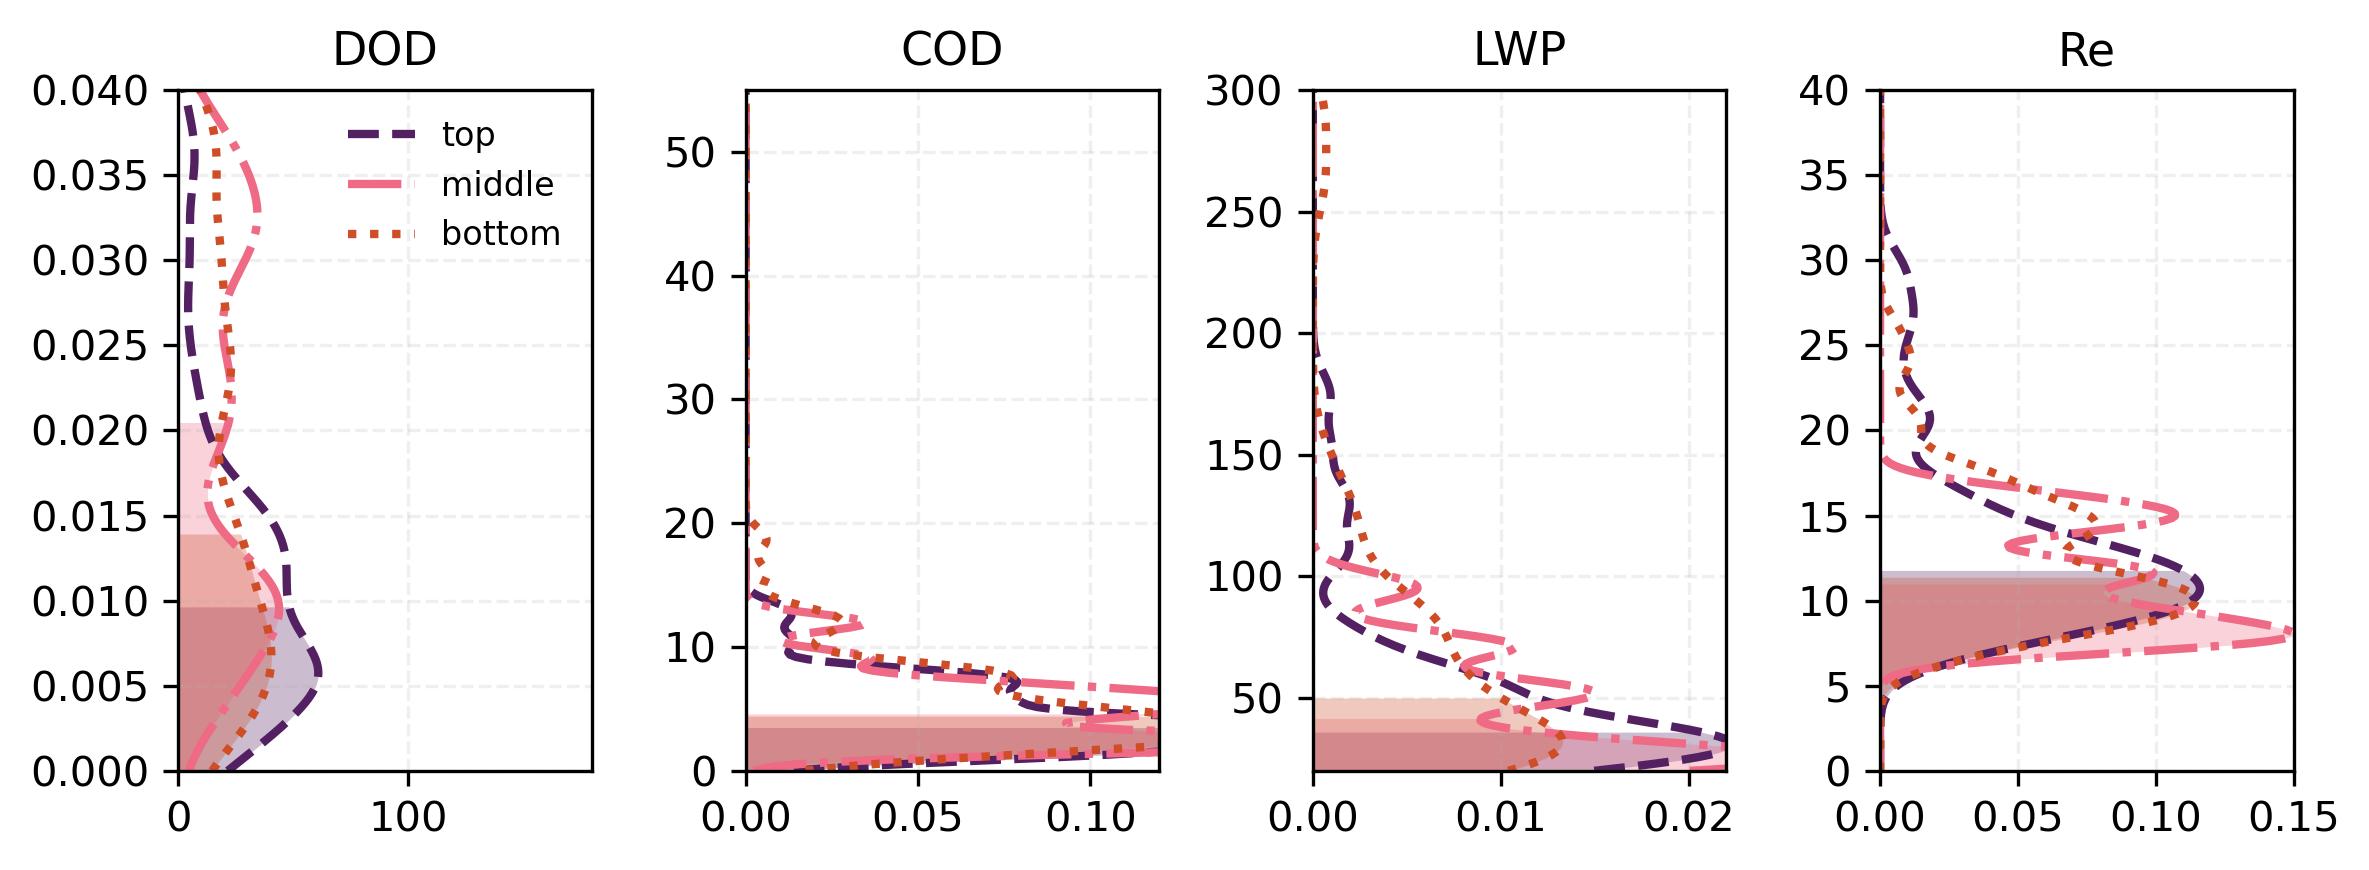

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---------- Prepare data ----------
df_plot = df[df["cat"].isin(["top", "middle", "bottom"])].copy()

cats = ["top", "middle", "bottom"]
vars4 = ["DOD", "COD", "LWP", "Re"]

styles = {"top": "--", "middle": "dashdot", "bottom": ":"}
colors = {"top": "#532162", "middle": "#ee6a85", "bottom": "#cf4e28"}

xlims = {"DOD": (0, 0.04), "COD": (0, 55), "LWP": (20, 300), "Re": (0, 40)}
ylims = {"DOD": (0, 180), "COD": (0, 0.12), "LWP": (0, 0.022), "Re": (0, 0.15)}

# ---------- Plot KDE PDFs ----------
fig, axes = plt.subplots(1, 4, figsize=(8, 3), dpi=300)

for ax, var in zip(axes, vars4):
    xmin, xmax = xlims[var]
    ymin, ymax = ylims[var]
    x = np.linspace(xmin, xmax, 300)

    for c in cats:
        y = df_plot.loc[df_plot["cat"].eq(c), var].to_numpy(float)
        y = y[np.isfinite(y) & (y > 0) & (y >= xmin) & (y <= xmax)]

        if y.size < 2:
            continue

        kde = gaussian_kde(y, bw_method=0.25)(x)
        med = np.median(y)
        mask = x <= med

        ax.plot(kde, x, color=colors[c], lw=2, ls=styles[c], label=c)
        ax.fill_betweenx(x[mask], kde[mask], 0, color=colors[c], alpha=0.3, lw=0)

        print(f"{var:>3s} | {c:<6s} median = {med:.3f}")

    ax.set_title(var, fontsize=11)
    ax.set_xlim(ymin, ymax)
    ax.set_ylim(xmin, xmax)
    ax.grid(alpha=0.2, ls="--")

axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## Dust-ACI in ENA, Fig. 3


===== All-data sensitivity =====

--- COD ---
   Top: slope = -0.0866, SE =  0.1438
Middle: slope =  0.5390, SE =  0.2664
Bottom: slope = -0.0916, SE =  0.1423

--- LWP ---
   Top: slope = -0.1168, SE =  0.1433
Middle: slope =  0.4697, SE =  0.2792
Bottom: slope = -0.1787, SE =  0.1406

--- Re ---
   Top: slope =  0.0125, SE =  0.1443
Middle: slope =  0.0333, SE =  0.3161
Bottom: slope =  0.2166, SE =  0.1395

===== LWP-stratified Re sensitivity =====

--- LWP 20–60 ---
   Top: slope = -0.1794, SE =  0.1596
Middle: slope =  nan, SE =  nan
Bottom: slope =  0.1896, SE =  0.1823

--- LWP 60–100 ---
   Top: slope =  nan, SE =  nan
Middle: slope =  nan, SE =  nan
Bottom: slope = -0.2196, SE =  0.3085

--- LWP >100 ---
   Top: slope =  nan, SE =  nan
Middle: slope =  nan, SE =  nan
Bottom: slope =  nan, SE =  nan


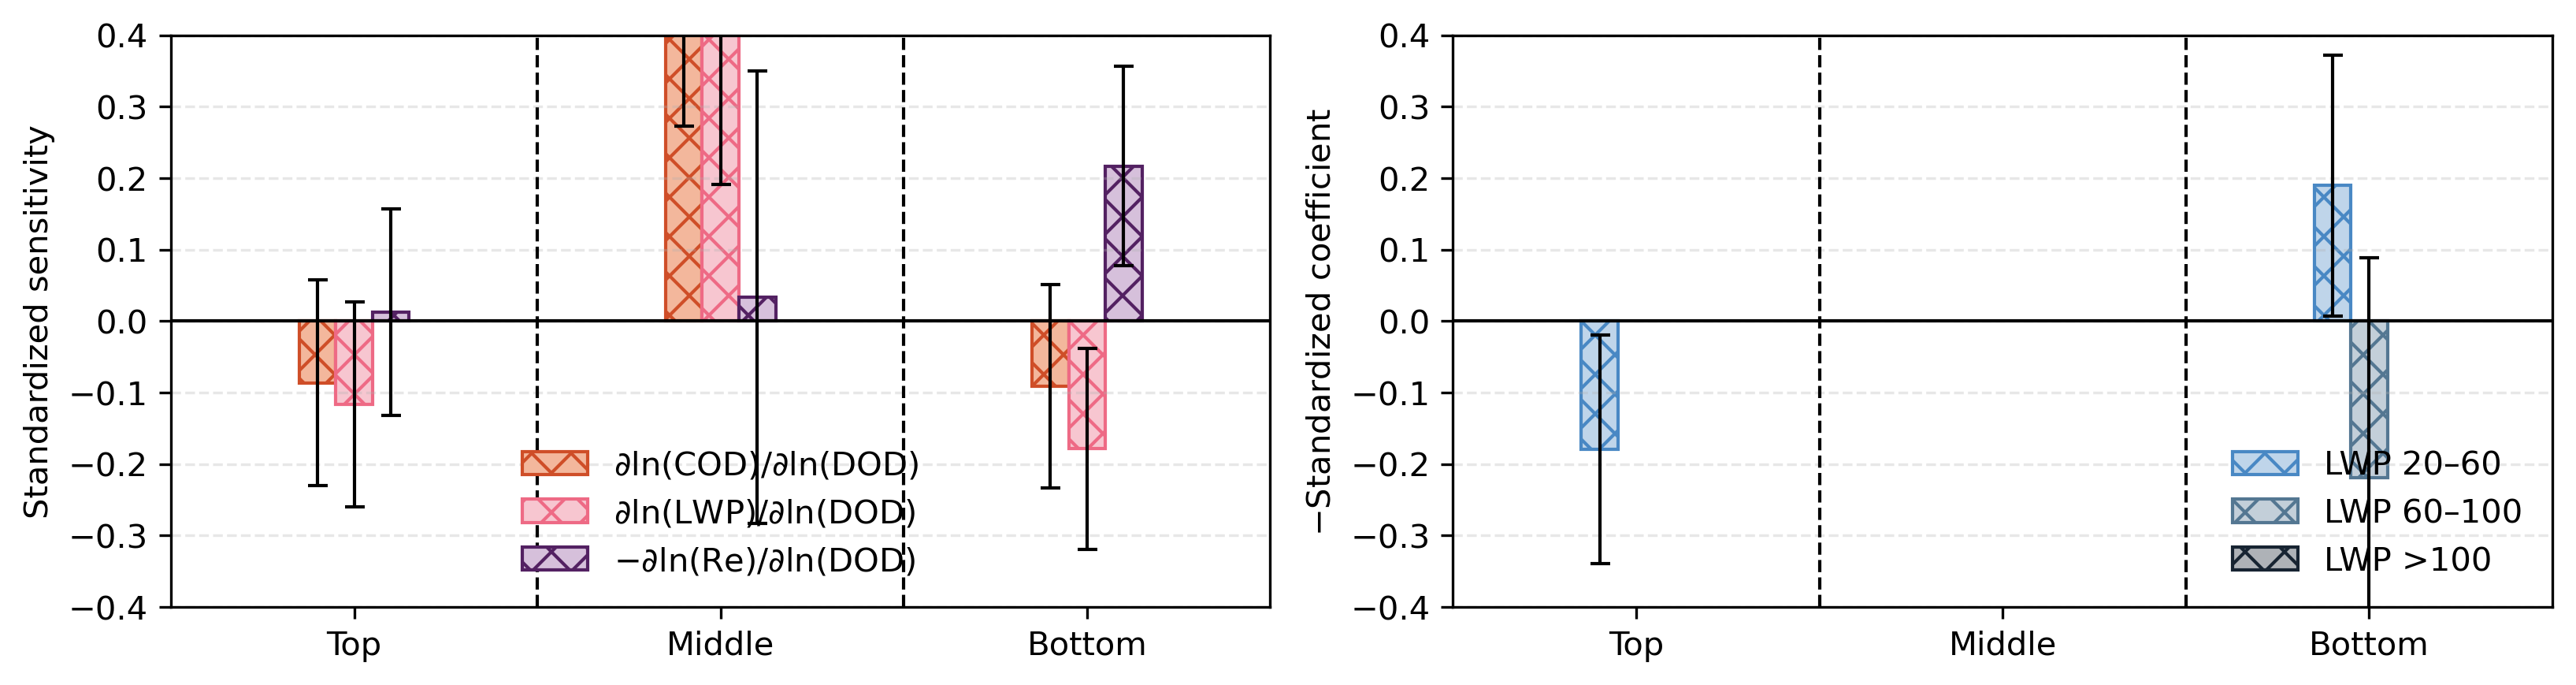

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import matplotlib.colors as mcolors

# ---------- Settings ----------
cats = ["top", "middle", "bottom"]
cat_labels = ["Top", "Middle", "Bottom"]
vars_order = ["COD", "LWP", "Re"]

labels = {
    "COD": r"$\partial \ln(\mathrm{COD})/\partial \ln(\mathrm{DOD})$",
    "LWP": r"$\partial \ln(\mathrm{LWP})/\partial \ln(\mathrm{DOD})$",
    "Re":  r"$-\partial \ln(\mathrm{Re})/\partial \ln(\mathrm{DOD})$",
}
sign = {"COD": 1, "LWP": 1, "Re": -1}

cols_all = ["#f3b79c", "#f7c6d0", "#d6c0db"]
edge_all = ["#cf4e28", "#ee6a85", "#532162"]
cols_bin = ["#4988C4", "#547792", "#172432"]

groups = [
    ("20–60",  lambda x: (x >= 20) & (x < 60)),
    ("60–100", lambda x: (x >= 60) & (x < 100)),
    (">100",   lambda x: x >= 100),
]

dod_min, dod_max = 1e-6, 5e-1
min_count, w = 10, 0.1

def lighten(c, a=0.65):
    rgb = np.array(mcolors.to_rgb(c))
    return tuple(rgb + (1 - rgb) * a)

def zscore(x):
    x = np.asarray(x, float)
    s = np.nanstd(x, ddof=1)
    return (x - np.nanmean(x)) / s if np.isfinite(s) and s > 0 else np.full_like(x, np.nan)

def slope_se(x, y, sgn=1):
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0) & (dod_min <= x) & (x <= dod_max)
    if m.sum() < min_count:
        return np.nan, np.nan, int(m.sum())

    lx, ly = zscore(np.log(x[m])), zscore(np.log(y[m]))
    mm = np.isfinite(lx) & np.isfinite(ly)
    if mm.sum() < min_count:
        return np.nan, np.nan, int(mm.sum())

    r = linregress(lx[mm], ly[mm])
    return r.slope * sgn, r.stderr, int(mm.sum())

# ---------- Clean data ----------
df0 = df[df["cat"].isin(cats)].copy()
for col in ["DOD", "COD", "LWP", "Re"]:
    df0[col] = pd.to_numeric(df0[col], errors="coerce")

df0 = (
    df0.replace([np.inf, -np.inf], np.nan)
       .dropna(subset=["cat", "DOD", "COD", "LWP", "Re"])
       .query("DOD > 0 and COD > 0 and LWP >= 20 and Re > 0")
)

# ---------- All-data sensitivity ----------
all_sens = {v: [] for v in vars_order}
all_se   = {v: [] for v in vars_order}

for c in cats:
    sub = df0[df0["cat"].eq(c)]
    for v in vars_order:
        s, se, _ = slope_se(sub["DOD"], sub[v], sign[v])
        all_sens[v].append(s)
        all_se[v].append(se)

print("\n===== All-data sensitivity =====")
for v in vars_order:
    print(f"\n--- {v} ---")
    for c, s, se in zip(cats, all_sens[v], all_se[v]):
        print(f"{c.capitalize():>6s}: slope = {s: .4f}, SE = {se: .4f}")

# ---------- LWP-stratified Re sensitivity ----------
sens = np.full((len(groups), len(cats)), np.nan)
se = np.full_like(sens, np.nan)

for j, c in enumerate(cats):
    sub = df0[df0["cat"].eq(c)]
    dod, re, lwp = sub["DOD"].to_numpy(), sub["Re"].to_numpy(), sub["LWP"].to_numpy()

    for i, (_, cond) in enumerate(groups):
        sens[i, j], se[i, j], _ = slope_se(dod[cond(lwp)], re[cond(lwp)], -1)

print("\n===== LWP-stratified Re sensitivity =====")
for i, (glabel, _) in enumerate(groups):
    print(f"\n--- LWP {glabel} ---")
    for c, s, sse in zip(cats, sens[i], se[i]):
        print(f"{c.capitalize():>6s}: slope = {s: .4f}, SE = {sse: .4f}")

# ---------- Plot ----------
fig, ax = plt.subplots(1, 2, figsize=(11, 3), dpi=300)
x = np.arange(len(cats))
errkw = dict(ecolor="k", elinewidth=1, capsize=3, capthick=1)

for j, v in enumerate(vars_order):
    ax[0].bar(
        x + (j - 1) * w, all_sens[v], w, yerr=all_se[v],
        color=cols_all[j], edgecolor=edge_all[j], lw=1,
        hatch="xx", error_kw=errkw, label=labels[v]
    )

for i, (glabel, _) in enumerate(groups):
    ax[1].bar(
        x + (i - 1) * w, sens[i], w, yerr=se[i],
        color=lighten(cols_bin[i]), edgecolor=cols_bin[i], lw=1,
        hatch="xx", error_kw=errkw, label=f"LWP {glabel}"
    )

for a, ylabel in zip(ax, ["Standardized sensitivity", r"$-\mathrm{Standardized\ coefficient}$"]):
    a.axhline(0, color="k", lw=1)
    a.vlines([0.5, 1.5], -0.4, 0.4, color="k", lw=1, ls="--")
    a.set(xlim=(-0.5, 2.5), xticks=x, xticklabels=cat_labels, ylim=(-0.4, 0.4), ylabel=ylabel)
    a.grid(axis="y", alpha=0.3, ls="--")
    a.legend(frameon=False)

plt.tight_layout()
plt.show()

### Percentage, Fig S3

In [3]:
df_ena = pd.read_csv("ENA_vertical_config.csv")
df_sgp = pd.read_csv("SGP_vertical_config.csv")


ENA counts:
cat     bottom  middle  top
season                     
DJF         33       3   57
MAM         18      12   90
JJA         23      13  117
SON         38      13   75

ENA percentage:
cat     bottom  middle   top
season                      
DJF       35.5     3.2  61.3
MAM       15.0    10.0  75.0
JJA       15.0     8.5  76.5
SON       30.2    10.3  59.5

SGP counts:
cat     bottom  middle  top
season                     
DJF          7       0   24
MAM         13       6   12
JJA         28      13   34
SON          9       5   15

SGP percentage:
cat     bottom  middle   top
season                      
DJF       22.6     0.0  77.4
MAM       41.9    19.4  38.7
JJA       37.3    17.3  45.3
SON       31.0    17.2  51.7


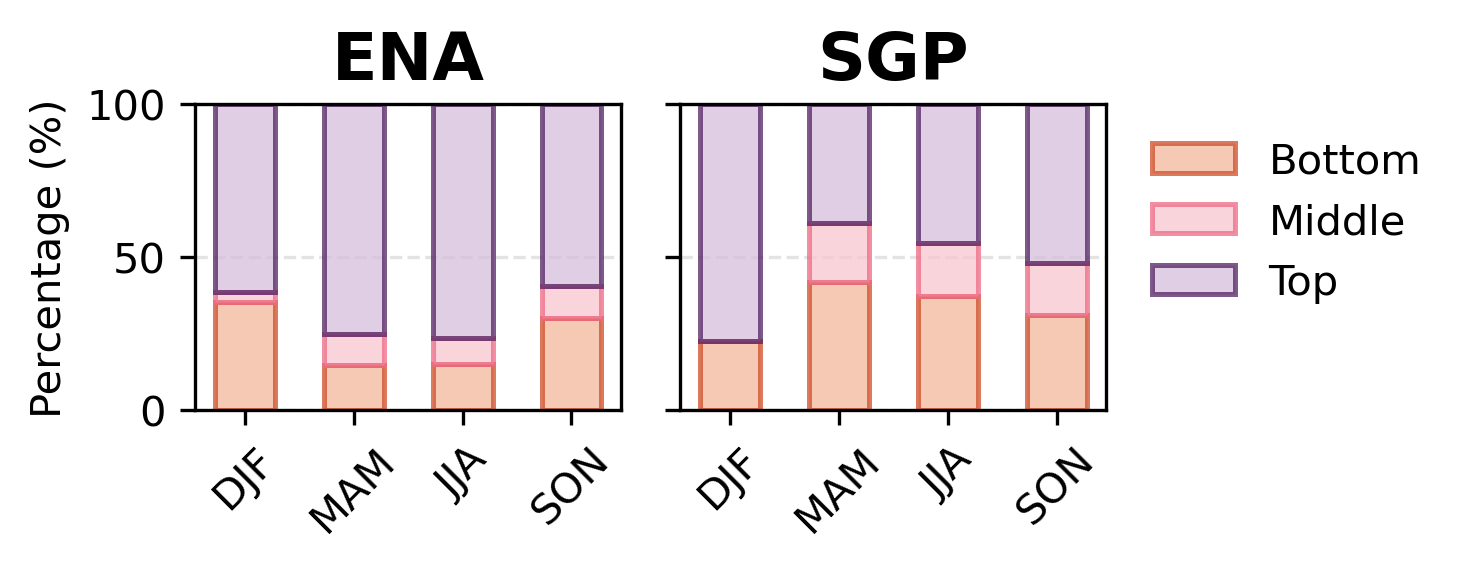

In [4]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

dfs = {"ENA": df_ena, "SGP": df_sgp}
smap = {12:"DJF",1:"DJF",2:"DJF",3:"MAM",4:"MAM",5:"MAM",6:"JJA",7:"JJA",8:"JJA",9:"SON",10:"SON",11:"SON"}
seasons, cats = ["DJF","MAM","JJA","SON"], ["bottom","middle","top"]
colors, edges = ["#f3b79c","#f7c6d0","#d6c0db"], ["#cf4e28","#ee6a85","#532162"]

fig, axes = plt.subplots(1, 2, figsize=(5, 2), dpi=300, sharey=True)

for ax, (site, d) in zip(axes, dfs.items()):
    d = d.copy()
    d["season"] = d["month"].map(smap)

    cnt = pd.crosstab(d["season"], d["cat"]).reindex(index=seasons, columns=cats, fill_value=0)
    pct = cnt.div(cnt.sum(1), axis=0).mul(100)

    print(f"\n{site} counts:\n{cnt}")
    print(f"\n{site} percentage:\n{pct.round(1)}")

    bot = np.zeros(len(pct))
    for c, fc, ec in zip(cats, colors, edges):
        ax.bar(pct.index, pct[c], bottom=bot, color=fc, edgecolor=ec,
               width=0.55, lw=1.2, alpha=0.75, label=c.capitalize())
        bot += pct[c].values

    ax.set_title(site, fontsize=16, weight="bold")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", ls="--", alpha=0.35)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Percentage (%)")
axes[1].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig("figsave/seasonal_prec.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Fractional occurrence of Top, Middle, and Bottom configurations at ENA and SGP, Fig S4a

Counts:
 cat  bottom  middle  top
ENA     112      41  339
SGP      57      24   85

Percentages:
 cat  bottom  middle   top
ENA    22.8     8.3  68.9
SGP    34.3    14.5  51.2


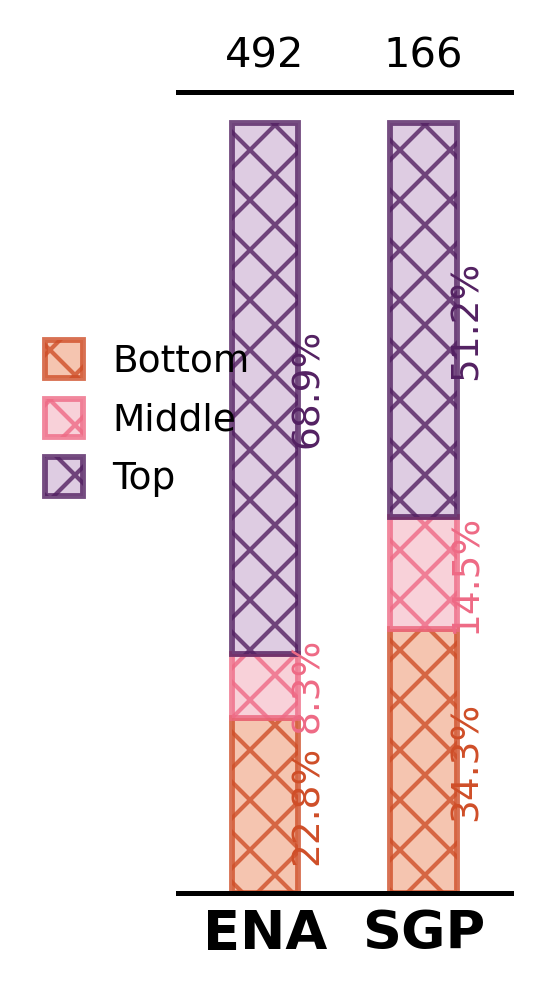

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dfs = {"ENA": df_ena, "SGP": df_sgp}

cats = ["bottom", "middle", "top"]
labels = {"bottom": "Bottom", "middle": "Middle", "top": "Top"}
colors = {"bottom": "#f3b79c", "middle": "#f7c6d0", "top": "#d6c0db"}
edges  = {"bottom": "#cf4e28", "middle": "#ee6a85", "top": "#532162"}

# ---------- Count and percentage ----------
cnt = pd.DataFrame({
    site: d["cat"].value_counts().reindex(cats, fill_value=0)
    for site, d in dfs.items()
}).T

pct = cnt.div(cnt.sum(axis=1), axis=0) * 100

print("Counts:\n", cnt)
print("\nPercentages:\n", pct.round(1))

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(2.2, 3.4), dpi=300)

x = np.arange(len(dfs))
bottom = np.zeros(len(dfs))

for c in cats:
    vals = pct[c].values

    ax.bar(
        x, vals, bottom=bottom, width=0.42,
        color=colors[c], edgecolor=edges[c],
        lw=1.4, alpha=0.8, hatch="xx",
        label=labels[c], zorder=2
    )

    for xi, v, b in zip(x, vals, bottom):
        if v > 3:
            ax.text(
                xi + 0.27, b + v / 2, f"{v:.1f}%",
                ha="center", va="center",
                rotation=90, fontsize=9,
                color=edges[c], zorder=10,
                clip_on=False
            )

    bottom += vals

# ---------- Total sample number ----------
for xi, site in zip(x, dfs.keys()):
    ax.text(
        xi, 106, f"{cnt.loc[site].sum():.0f}",
        ha="center", va="bottom",
        fontsize=10, zorder=10,
        clip_on=False
    )

# ---------- Formatting ----------
ax.set_xticks(x)
ax.set_xticklabels(list(dfs.keys()), fontsize=13, weight="bold")
ax.set_xlim(-0.55, len(dfs) - 0.45)
ax.set_ylim(0, 112)
ax.set_yticks([])
ax.tick_params(axis="x", length=0)

for s in ["left", "right", "top"]:
    ax.spines[s].set_visible(False)

ax.spines["bottom"].set_linewidth(1.2)
ax.axhline(104, color="k", lw=1.2, clip_on=False, zorder=1)

ax.legend(
    frameon=False, fontsize=9,
    loc="center left", bbox_to_anchor=(-0.50, 0.55),
    handlelength=1.0, handleheight=1.2
)

plt.tight_layout()
plt.show()